In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

load_dotenv(override=True)
logging.langsmith("CH20-PATTERN")

LangSmith 추적을 시작합니다.
[프로젝트명]
CH20-PATTERN


# Supervisor Advanced 

1. 평가 전담 노드 분리 - `RelevanceChecker`
2. 명시적 평가 기준 - `EvaluationResult` 체크리스트 
3. 피드백 루프 
    - `RelevanceChecker`가 실패 원인과 재시도 지시를 State에 저장
    - Supervisor가 피드백을 메시지에 주입하여 각 하위 에이전트에게 명시적으로 전달
    - 이를 위해 결정권이 Supervisor에 있음을 프롬프트에 명시
4. 강제 종료 노드 추가 - `EndwithWarning` 
    - `recursion_limit` 의존 제거
    - Supervisor가 `END_WARNING` 선택 시 실행되는 명시적 노드
    - 최종 점수, 미통과 항목, 경고 메시지를 State에 기록하고 종료

In [2]:
import functools
import operator
from typing import Annotated, Literal, Sequence

from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_teddynote.tools.tavily import TavilySearch
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field
from pydantic_core import PydanticUndefined
from typing_extensions import TypedDict

## 1. 상수

In [3]:
# 모델 버전 
MODEL_NAME = "gpt-4o-mini"

In [4]:
# 최대 재시도 횟수 — 초과 시 Supervisor가 END_WARNING 결정
MAX_RETRIES = 2

In [5]:
# EvaluationResult 필드명을 코드에서 단일 관리
# Researcher 재위임 트리거 조건 — 이 필드가 False이면 Writer가 아닌 Researcher로
# 필드명이 바뀌면 여기만 수정하면 RESULT REVIEW 섹션도 자동 반영
RESEARCHER_RETRIGGER_FIELD = "has_minimum_news_count"

## 2. EvaluationResult - 평가 기준
- description → SystemMessage 체크리스트 자동 생성
- 기준 변경 시 여기만 수정하면 SystemMessage, RESULT REVIEW 모두 반영

In [6]:
class EvaluationResult(BaseModel):
    passed: bool = Field(
        description="True if ALL criteria are met, False otherwise"
    )
    # ★ 체크리스트 — 전부 True일 때만 passed = True
    has_minimum_news_count: bool = Field(
        description="At least 3 news items are present"
    )
    has_required_structure: bool = Field(
        description="Each item has title / summary(2-3 sentences) / implication"
    )
    is_it_focused: bool = Field(
        description="Content is relevant to IT domain"
    )
    is_within_length: bool = Field(
        description="Each item is concise, not excessively long"
    )
    
    # Supervisor가 재위임 시 Writer에게 전달할 명시적 피드백
    issues: list[str] = Field(
        default_factory=list,
        description="Specific issues found. Empty if passed."
    )
    retry_instruction: str = Field(
        default="",
        description="Actionable instruction for next attempt. Empty if passed."
    )

## 3. STATE

In [7]:
class AgentState(TypedDict):
    messages:          Annotated[Sequence[BaseMessage], operator.add]
    next:              str
    retry_count:       int    # 재시도 횟수 누적 — Supervisor 판단에 활용
    evaluation_result: dict   # EvaluationResult.model_dump() + score 저장

## 4. LLM, TOOLS

In [8]:
llm = ChatOpenAI(model=MODEL_NAME, temperature=0)
tavily_tool = TavilySearch(max_results=5)

## 5. AGENT

### 5-1. AGENT NODE Helper

In [9]:
def agent_node(state: AgentState, agent, name: str) -> dict:
    result = agent.invoke(state)
    return {
        "messages": [
            HumanMessage(content=result["messages"][-1].content, name=name)
        ]
    }

### 5-2. RESEARCHER AGENT

In [10]:
researcher_agent = create_agent(
    llm,
    tools=[tavily_tool],
    system_prompt=(
        "You are an IT news researcher.\n\n"
        "RESPONSIBILITIES:\n"
        "- Search for the latest Korean IT news using the search tool\n"
        "- Collect at least 3 recent and relevant news items\n"
        "- For each news item, extract: title, source, date, and key content\n\n"
        "OUTPUT FORMAT:\n"
        "1. [제목] | [출처] | [날짜]\n"
        "   요약: ...\n\n"
        "IMPORTANT: Focus ONLY on research. Do NOT write a briefing."
    ),
)
researcher_node = functools.partial(
    agent_node, agent=researcher_agent, name="Researcher"
)

### 5-3. WRITER AGENT

In [11]:
writer_agent = create_agent(
    llm,
    tools=[],
    system_prompt=(
        "You are a Korean IT news briefing writer.\n\n"
        "OUTPUT FORMAT (반드시 아래 구조로 작성):\n"
        "오늘의 IT 뉴스 브리핑\n"
        "================================\n"
        "각 뉴스마다:\n"
        "  ▶ 제목\n"
        "  • 요약 (2~3문장)\n"
        "  • 시사점 (1문장)\n"
        "================================\n"
        "IMPORTANT: Use ONLY the provided research. Write in Korean."
    ),
)
writer_node = functools.partial(
    agent_node, agent=writer_agent, name="Writer"
)

## 6. Evaluation 

### 6-1. 생성 함수 

- 평가를 위한 체크리스트 스키마, 검토 결과 등을 생성하는 함수 
- system prompt로 하드코딩 하지 않고 함수로 정의함 

In [12]:
def build_criteria_from_schema(model: type[BaseModel]) -> str:
    """
    EvaluationResult의 bool 필드 description만 추출
    → RelevanceChecker SystemMessage 체크리스트 구성
    """
    criteria_fields = {
        name: field
        for name, field in model.model_fields.items()
        if (
            field.annotation is bool
            and field.default is PydanticUndefined
        )
    }
    lines = [
        f"{i}. {name:<30} : {field.description}"
        for i, (name, field) in enumerate(criteria_fields.items(), 1)
    ]
    return "\n".join(lines)


def build_checker_system_message() -> str:
    """
    EvaluationResult 스키마 → RelevanceChecker SystemMessage 자동 생성
    기준 변경 시 EvaluationResult만 수정하면 여기도 자동 반영
    """
    criteria_text = build_criteria_from_schema(EvaluationResult)
    return (
        "You are a strict quality evaluator for IT news briefings.\n\n"
        "Evaluate the briefing against ALL criteria below.\n"
        "passed = True ONLY if every criterion is True.\n\n"
        "[ Evaluation Criteria ]\n"
        f"{criteria_text}\n\n"
        "If any criterion fails:\n"
        "- List specific issues in the 'issues' field\n"
        "- Write a clear, actionable retry_instruction"
    )


def build_supervisor_review_section() -> str:
    """
    RESULT REVIEW 섹션 자동 생성
    EvaluationResult 필드명(RESEARCHER_RETRIGGER_FIELD)과
    MAX_RETRIES를 코드 상수에서 참조
    → 필드명/재시도 횟수 변경 시 상수만 수정하면 자동 반영
    → 프롬프트와 스키마 사이의 묵시적 결합 제거
    """
    return (
        f"RESULT REVIEW (after receiving RelevanceChecker evaluation):\n"
        f"- passed = True"
        f"                                    → select FINISH\n"
        f"- passed = False, retry_count < {MAX_RETRIES}"
        f"             → re-assign to Writer with retry_instruction\n"
        f"  (if {RESEARCHER_RETRIGGER_FIELD} failed"
        f"  → re-assign to Researcher instead)\n"
        f"- passed = False, retry_count >= {MAX_RETRIES}"
        f"           → select END_WARNING\n"
    )

In [13]:
# 모듈 로드 시 1회 생성
CHECKER_SYSTEM_MESSAGE  = build_checker_system_message()
SUPERVISOR_REVIEW_SECTION = build_supervisor_review_section()

### 6-2. Relevance Check

In [14]:
def compute_score(result: EvaluationResult) -> float:
    """
    SCORE 단순 평균 계산 
    - valuationResult의 bool 체크리스트 항목만 추출하여 단순 평균
    - 항목 추가/제거 시 자동으로 반영됨
    """
    criteria = [
        getattr(result, name)
        for name, field in EvaluationResult.model_fields.items()
        if (
            field.annotation is bool
            and field.default is PydanticUndefined
            and name != "passed"   # passed는 집계 대상 제외
        )
    ]
    return sum(criteria) / len(criteria) if criteria else 0.0


def relevance_checker_node(state: AgentState) -> dict:
    """
    평가 전담 
    - 평가 결과를 state에 저장하고 항상 Supervisor로 복귀
    - 재시도/종료/강제종료 판단은 Supervisor가 담당
    """
    last_message  = state["messages"][-1].content
    current_retry = state.get("retry_count", 0)

    evaluation_prompt = [
        SystemMessage(content=CHECKER_SYSTEM_MESSAGE),
        HumanMessage(content=f"Briefing to evaluate:\n\n{last_message}")
    ]

    checker_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    result: EvaluationResult = (
        checker_llm.with_structured_output(EvaluationResult)
        .invoke(evaluation_prompt)
    )

    score = compute_score(result)

    return {
        "retry_count":       current_retry + (0 if result.passed else 1),
        "evaluation_result": {**result.model_dump(), "score": score},
    }

## 7. SUPERVISOR

- 모든 판단과 결정권 보유 
- 초기 위임 + 결과 수신 + 평가 검토 + 재위임/종료/강제종료 결정 
- RESULT REVIEW 섹션은 코드 상수에서 자동 생성 

In [15]:
members          = ["Researcher", "Writer"]
options_for_next = ["Researcher", "Writer", "FINISH", "END_WARNING"]

In [16]:
class RouteResponse(BaseModel):
    next: Literal["Researcher", "Writer", "FINISH", "END_WARNING"]

In [17]:
supervisor_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a supervisor managing: {members}.\n\n"

        "WORKFLOW:\n"
        "1. Start with Researcher to gather IT news\n"
        "2. Then assign Writer to create the briefing\n\n"

        # ★ RESULT REVIEW — 코드 상수에서 자동 생성
        #   EvaluationResult 필드명, MAX_RETRIES 모두 코드에서 참조
        "{review_section}"

        "RULE: DO NOT perform any work yourself — always delegate.\n\n"
        "Select one of: {options}"
    ),
    MessagesPlaceholder(variable_name="messages"),
    ("system", "Who should act next? Select one of: {options}"),
]).partial(
    members=", ".join(members),
    options=str(options_for_next),
    review_section=SUPERVISOR_REVIEW_SECTION,   # 자동 생성된 섹션 주입
)

In [18]:
def supervisor_agent(state: AgentState) -> dict:
    messages    = list(state["messages"])
    eval_result = state.get("evaluation_result", {})

    # 평가 결과가 있으면 Supervisor가 직접 판단하도록 메시지 주입
    # "당신이 판단하세요" — 결정권이 Supervisor에게 있음을 명시
    if eval_result:
        score = eval_result.get("score", 0)
        messages.append(HumanMessage(
            content=(
                f"[RelevanceChecker 평가 결과 — 당신이 판단하세요]\n"
                f"통과 여부    : {'PASS' if eval_result.get('passed') else 'FAIL'}\n"
                f"점수         : {score:.2f} ({int(score * 5)}/5 항목 통과)\n"
                f"실패 항목    : {', '.join(eval_result.get('issues', []))}\n"
                f"재시도 지시  : {eval_result.get('retry_instruction', '')}\n"
                f"현재 재시도  : {state.get('retry_count', 0)}/{MAX_RETRIES}회"
            ),
            name="RelevanceChecker"
        ))

    chain  = supervisor_prompt | llm.with_structured_output(RouteResponse)
    result = chain.invoke({**state, "messages": messages})
    return {"next": result.next}

In [19]:
def end_with_warning_node(state: AgentState) -> dict:
    """
    강제 종료 노드 
    - Supervisor가 END_WARNING을 선택했을 때 실행
    """
    eval_result = state.get("evaluation_result", {})
    score       = eval_result.get("score", 0)
    return {
        "messages": [HumanMessage(
            content=(
                f"[경고] Supervisor 판단 — 최대 재시도({MAX_RETRIES}회) 초과.\n"
                f"최종 점수  : {score:.2f} ({int(score * 5)}/5 항목 통과)\n"
                f"미통과 항목: {', '.join(eval_result.get('issues', []))}\n"
                "최종 결과물의 품질이 기준에 미달할 수 있습니다."
            ),
            name="System"
        )]
    }

## 8. Graph

In [20]:
# 라우팅 함수 
def get_next(state: AgentState) -> str:
    return state["next"]

In [21]:
workflow = StateGraph(AgentState)

workflow.add_node("Supervisor",       supervisor_agent)
workflow.add_node("Researcher",       researcher_node)
workflow.add_node("Writer",           writer_node)
workflow.add_node("RelevanceChecker", relevance_checker_node)
workflow.add_node("EndWithWarning",   end_with_warning_node)

workflow.add_edge(START, "Supervisor")
workflow.add_edge("Researcher", "Supervisor")
workflow.add_edge("Writer", "RelevanceChecker")
workflow.add_edge("RelevanceChecker", "Supervisor")

# ★ Supervisor → 4방향 분기 (모든 결정권 보유)
workflow.add_conditional_edges(
    "Supervisor",
    get_next,
    {
        "Researcher":  "Researcher",     # 원천 데이터 부족 → 재수집
        "Writer":      "Writer",         # 브리핑 품질 미달 → 재작성
        "FINISH":      END,              # 평가 통과 → 종료
        "END_WARNING": "EndWithWarning", # 재시도 한계 초과 → 경고 후 종료
    },
)

workflow.add_edge("EndWithWarning", END)

graph = workflow.compile(checkpointer=MemorySaver())

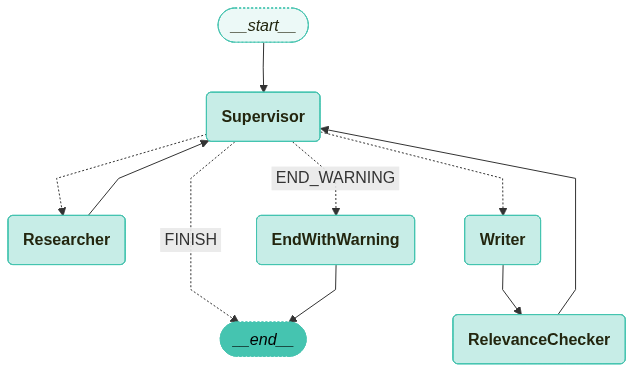

In [23]:
from langchain_teddynote.graphs import visualize_graph
visualize_graph(graph)

## 9. 실행

In [24]:
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import random_uuid, invoke_graph

In [25]:
USER_QUERY = "오늘의 IT 뉴스 브리핑 만들어주세요."

In [26]:
config = RunnableConfig(
    recursion_limit=20,
    configurable={"thread_id": random_uuid()}
)

In [27]:
inputs = {
    "messages":          [HumanMessage(content=USER_QUERY)],
    "retry_count":       0,
    "evaluation_result": {},
}

invoke_graph(graph, inputs, config)


🔄 Node: Supervisor 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
next:
Researcher

🔄 Node: model in [Researcher] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  tavily_web_search (call_gIyUnyPSY0S10SS4TBhh2Blk)
 Call ID: call_gIyUnyPSY0S10SS4TBhh2Blk
  Args:
    query: Korean IT news

🔄 Node: tools in [Researcher] 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: tavily_web_search

[{"url": "https://www.itnews.com.au/tag/korea", "title": "korea - iTnews - Page 1 of 3", "content": "Breaking korea news, analysis and opinion, tailored for Australian CIOs, IT ... North Korean hackers stole US$721 million in cryptocurrency from Japan.", "score": 0.9997918, "raw_content": "## LEO satellite operators could be beyond Australian data laws\n\n## iTnews Executive Retreats: Navigating Leadership in the 

In [29]:
# 최종 결과 확인 
final_state = graph.get_state(config).values

print("\n=== 평가 이력 ===")
print(f"재시도 횟수  : {final_state.get('retry_count', 0)}")
eval_r = final_state.get("evaluation_result", {})
if eval_r:
    score = eval_r.get("score", 0)
    print(f"통과 여부   : {'PASS' if eval_r.get('passed') else 'FAIL'}")
    print(f"점수        : {score:.2f} ({int(score * 4)}/4 항목 통과)")
    print("체크리스트  :")
    for name, field in EvaluationResult.model_fields.items():
        if (
            field.annotation is bool
            and field.default is PydanticUndefined
            and name != "passed"
        ):
            mark = "✅" if eval_r.get(name) else "❌"
            print(f"  {mark} {name}")
    if eval_r.get("issues"):
        print(f"이슈        : {', '.join(eval_r['issues'])}")

print("\n=== 최종 브리핑 ===")
print(final_state["messages"][-1].content)


=== 평가 이력 ===
재시도 횟수  : 0
통과 여부   : PASS
점수        : 1.00 (4/4 항목 통과)
체크리스트  :
  ✅ has_minimum_news_count
  ✅ has_required_structure
  ✅ is_it_focused
  ✅ is_within_length

=== 최종 브리핑 ===
오늘의 IT 뉴스 브리핑
▶ 한국 인공지능 및 소프트웨어 산업 협회, 2026년 공공 IT 수요 브리핑 발표
• 한국 인공지능 및 소프트웨어 산업 협회(KOSA)는 2026년 소프트웨어 및 ICT 장비 수요 예측 브리핑을 3월 31일 서울 포스코타워에서 개최한다고 밝혔다. 이 브리핑은 약 2,500개 기관의 정보화 프로젝트를 대상으로 하여 기업들이 사업 전략을 수립하는 데 도움을 줄 것으로 기대된다.
• 이는 기업들이 향후 IT 시장의 변화를 예측하고 전략을 세우는 데 중요한 기회가 될 것이다.

▶ 스마트 테크 코리아 2026, 아시아의 혁신 기술 플랫폼으로 자리매김
• 2026년 6월 10일부터 12일까지 개최되는 스마트 테크 코리아 2026에서는 AI, 로봇공학, 클라우드 등 다양한 혁신 기술이 선보일 예정이다. 이 행사는 아시아의 기술 생태계에서 중요한 플랫폼으로 자리잡고 있으며, 기업 간 네트워킹과 비즈니스 매칭 프로그램도 포함된다.
• 이는 아시아 지역의 기술 혁신과 협업을 촉진하는 중요한 행사로 평가된다.

▶ 한국 AI 기업들, 산업의 주목받는 주역으로 부상
• 2026년 자동화 월드에서 한국의 AI 기업들이 주목받고 있으며, 이들은 물리적 AI 시대를 이끌고 있다. 그러나 이들 기업이 초기의 약속을 유지할 수 있을지는 불확실하다는 분석이 제기되고 있다.
• 이는 한국 AI 기업들이 글로벌 시장에서 지속 가능한 경쟁력을 갖추기 위해 해결해야 할 과제가 있음을 시사한다.


> 각자 LangSmith Tracing 진행 

<img src="asset/langsmith_11.png">

---
End of Documents